In [2]:
import pandas as pd
import numpy as np
import os

def backtest(average_scores_df, stock):
    average_scores_df = average_scores_df[['datetime', 'instrument', 'score']]
    average_scores_df['datetime'] = average_scores_df['datetime'].astype('datetime64[ns]')
    average_scores_df = average_scores_df.sort_values(by=['datetime', 'instrument'], ascending=[True, True])
    average_scores_df = average_scores_df[average_scores_df['instrument'].isin(stock)]

    stock_df = pd.read_csv('../dataset/hs300_2018_2023_new_1.csv')
    stock_df['dt'] = pd.to_datetime(stock_df['dt'])
    stock_df = stock_df[['kdcode', 'dt', 'close']]
    stock_df = stock_df.rename(columns={'kdcode': 'instrument', 'dt': 'datetime'})
    stock_df = stock_df.sort_values(by=['instrument', 'datetime'])
    stock_df['close_r'] = stock_df['close'] / stock_df['close'].shift(1)
    df_trade = stock_df[stock_df['datetime'] > '2022-12-31']

    x = pd.merge(df_trade, average_scores_df, on=['datetime', 'instrument'], how='outer')
    trade_date_unique = df_trade['datetime'].unique()
    df_return = pd.DataFrame()

    for date in trade_date_unique:
        x_day = x[x['datetime'] == date]
        r_day = x_day.nlargest(10, columns='score').close_r.mean()
        r_day = r_day - 1
        b = {'datetime': date, 'daily_return': r_day}
        df_return = df_return.append(b, ignore_index=True)

    portfolio_df_performance = df_return.set_index(['datetime'])

    alpha_df_performance = pd.DataFrame()
    alpha_df_performance['portfolio_daily_return'] = portfolio_df_performance['daily_return']
    alpha_df_performance['portfolio_net_value'] = (alpha_df_performance['portfolio_daily_return'] + 1).cumprod()

    net_value_columns = ['portfolio_net_value']

    alpha_statistics_df = pd.DataFrame(index=alpha_df_performance[net_value_columns].columns,
                                        columns=["年化收益", "年化波动率", "最大回撤率", "夏普率", "Calmar", "IR"])

    alpha_df_performance.index = pd.to_datetime(alpha_df_performance.index)
    alpha_statistics_df.loc[:, "年化收益"] = np.mean((alpha_df_performance[net_value_columns].tail(1)) ** (252 / len(alpha_df_performance)) - 1)
    alpha_statistics_df.loc[:, "年化波动率"] = np.std(alpha_df_performance[net_value_columns] / alpha_df_performance[net_value_columns].shift(1) - 1) * np.sqrt(252)
    alpha_statistics_df.loc[:, "最大回撤率"] = np.min((alpha_df_performance[net_value_columns] - alpha_df_performance[net_value_columns].cummax()) / alpha_df_performance[net_value_columns].cummax())
    alpha_statistics_df.loc[:, "夏普率"] = alpha_statistics_df["年化收益"] / alpha_statistics_df["年化波动率"]
    alpha_statistics_df.loc[:, "Calmar"] = alpha_statistics_df["年化收益"] / abs(alpha_statistics_df["最大回撤率"])
    alpha_statistics_df.loc[:, "IR"] = np.mean(alpha_df_performance[net_value_columns] / alpha_df_performance[net_value_columns].shift(1) - 1) * np.sqrt(252) / np.std(alpha_df_performance[net_value_columns] / alpha_df_performance[net_value_columns].shift(1) - 1)

    return alpha_statistics_df

def get_merged_score_df(base_path, prediction_index):
    score_dfs = []
    prediction_path = os.path.join(base_path, f'prediction_{prediction_index}')
    
    for j in range(20):
        folder_path = os.path.join(prediction_path, str(j))
        all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]
        
        for file in all_files:
            df = pd.read_csv(file)
            score_dfs.append(df)
    
    # 合并所有score_dfs并取均值
    merged_df = pd.concat(score_dfs).groupby(['dt', 'kdcode']).mean().reset_index()
    merged_df.rename(columns={'kdcode': 'instrument', 'dt' : 'datetime'}, inplace=True)
    return merged_df

# 主程序
base_path = '/home/liyuante/20240707_csi300_0.8_5_10_ns2'
d = pd.read_csv('../dataset/hs300_2018_2023_new_1.csv')
stock = d['kdcode'].unique()

results = []

for i in range(20):
    average_scores_df = get_merged_score_df(base_path, i)
    result = backtest(average_scores_df, stock)
    result = result[["年化收益", "年化波动率", "最大回撤率", "夏普率", "Calmar", "IR"]]  # 只保留6个指标
    result['folder'] = i
    results.append(result)

# 显示结果
final_df = pd.concat(results).reset_index(drop=True)
print(final_df)


        年化收益     年化波动率     最大回撤率       夏普率    Calmar        IR  folder
0   0.370808  0.223121 -0.134722  1.661915  2.752397  1.576103       0
1   0.188893  0.213353 -0.129511  0.885352  1.458506  0.987501       1
2   0.363549  0.195334 -0.108877  1.861161  3.339074  1.647542       2
3   0.477289  0.213651 -0.117700  2.233963  4.055148  1.991748       3
4   0.220180  0.200894 -0.118112  1.096004  1.864159  1.175756       4
5   0.537565  0.226574 -0.102603  2.372586  5.239282  2.070961       5
6   0.196133  0.193711 -0.141454  1.012508  1.386552  0.980039       6
7   0.320714  0.205785 -0.125345  1.558492  2.558650  1.489571       7
8   0.216533  0.198245 -0.102903  1.092251  2.104246  1.137760       8
9   0.323540  0.219397 -0.105618  1.474682  3.063305  1.457924       9
10  0.359340  0.198910 -0.098246  1.806547  3.657558  1.605835      10
11  0.412193  0.191840 -0.082069  2.148626  5.022507  1.857716      11
12  0.453076  0.204095 -0.100255  2.219921  4.519219  1.898473      12
13  0.

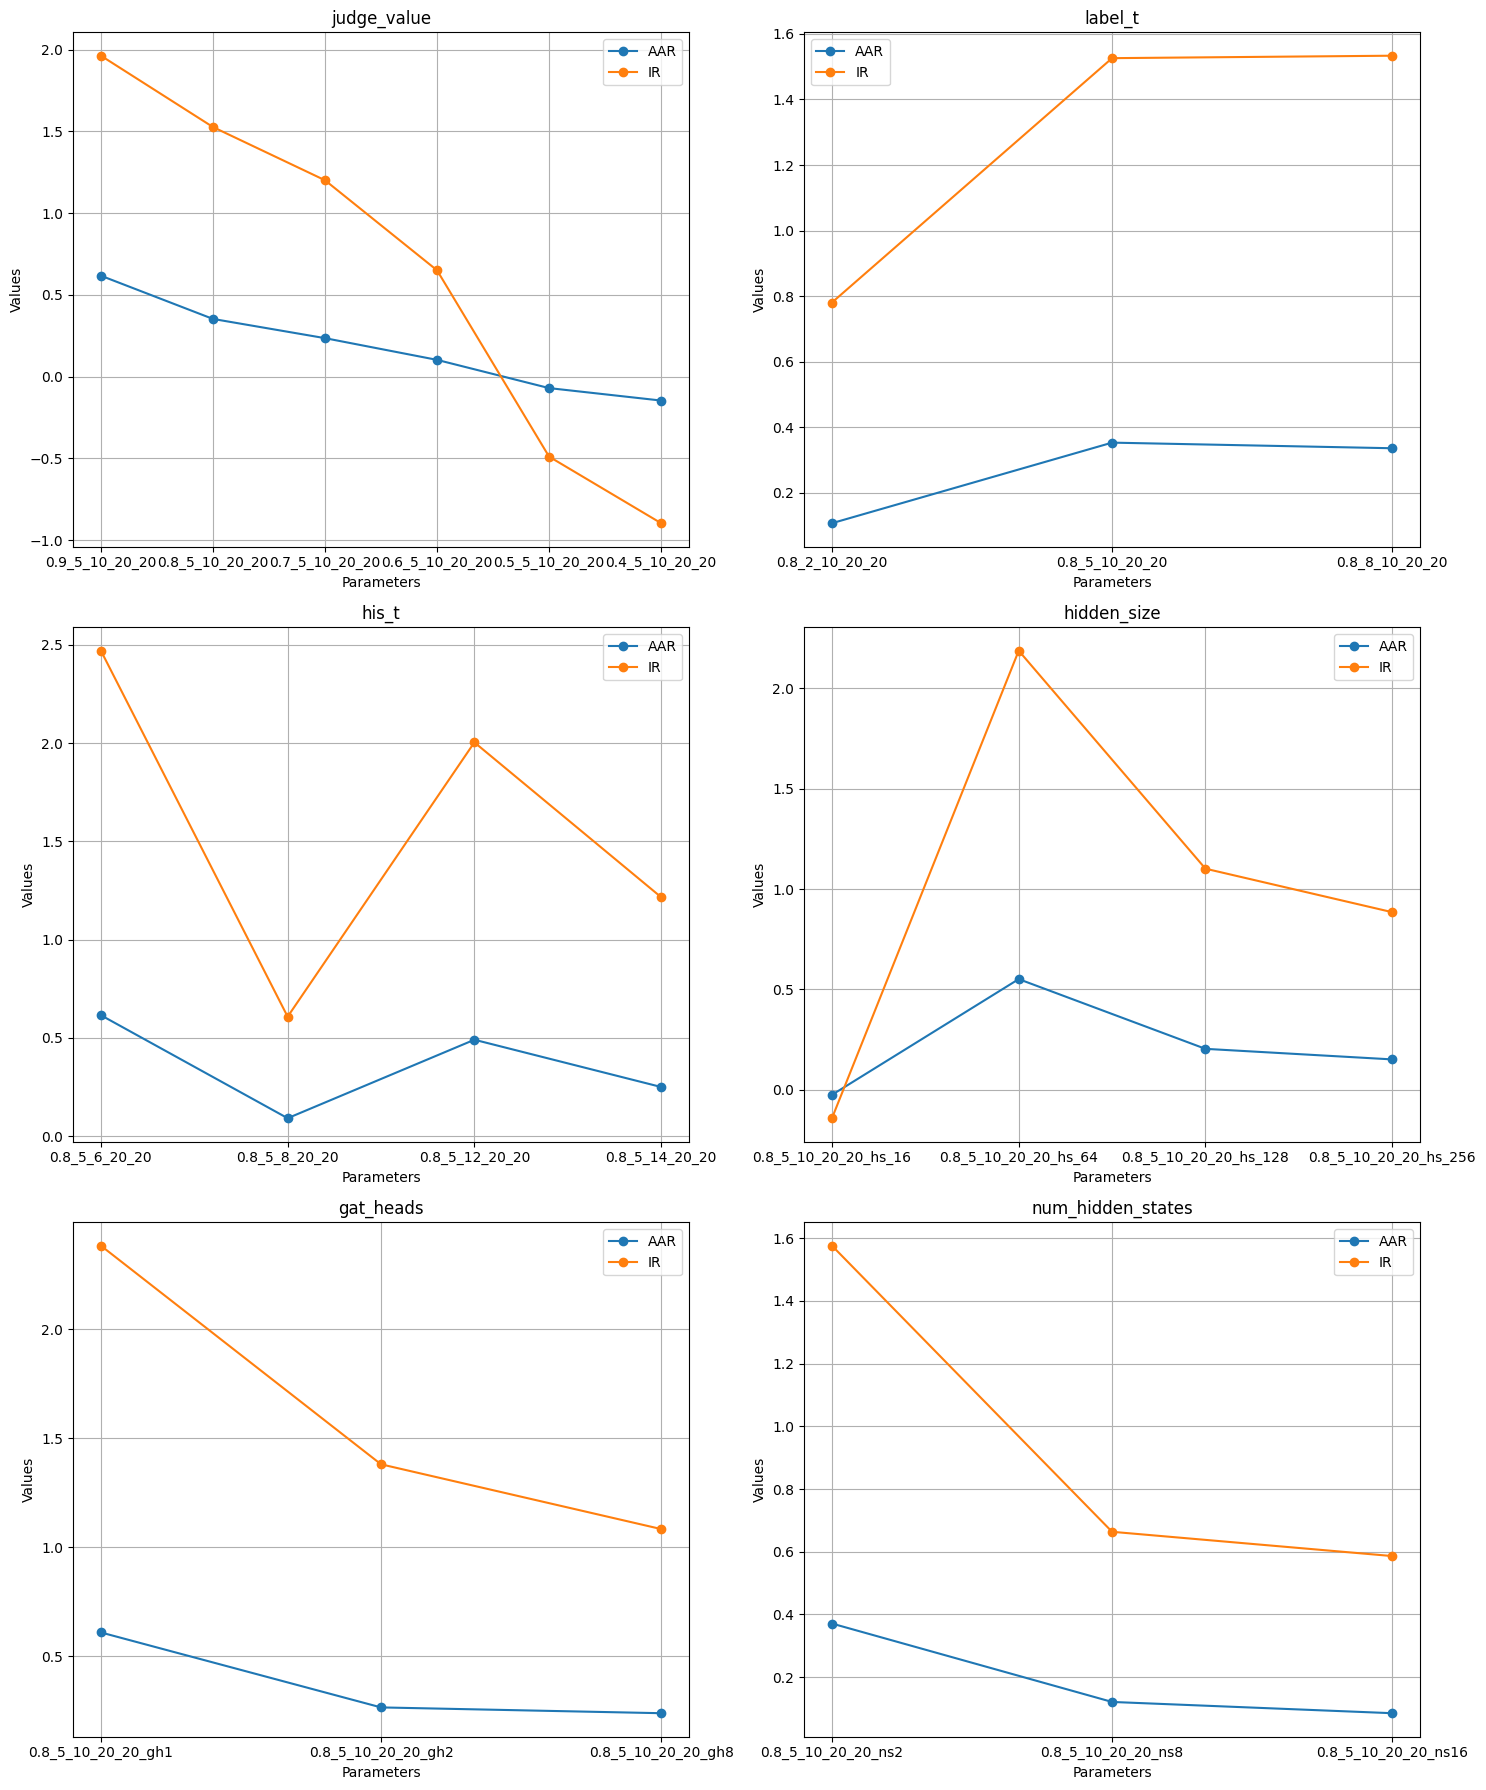

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for the different parameter settings

data = {
    'judge_value': {
        'params': ['0.9', '0.8', '0.7', '0.6', '0.5', '0.4'],
        'AAR': [0.616819, 0.352498, 0.234912, 0.102060, -0.070595, -0.146778],
        'IR': [1.962465, 1.526197, 1.200668, 0.649852, -0.489760, -0.896947]
    },
    'label_t': {
        'params': ['2', '5', '8'],
        'AAR': [0.106532, 0.352498, 0.335363],
        'IR': [0.780286, 1.526197, 1.533677]
    },
    'his_t': {
        'params': ['6', '8', '10', '12', '14'],
        'AAR': [0.615723, 0.091748, 0.352498, 0.490968, 0.250563],
        'IR': [2.470333, 0.608266, 2.003995, 1.216348]
    },
    'hidden_size': {
        'params': ['0.8_5_10_20_20_hs_16', '0.8_5_10_20_20_hs_64', '0.8_5_10_20_20_hs_128', '0.8_5_10_20_20_hs_256'],
        'AAR': [-0.025242, 0.551383, 0.203915, 0.151250],
        'IR': [-0.141760, 2.187934, 1.101704, 0.884965]
    },
    'gat_heads': {
        'params': ['0.8_5_10_20_20_gh1', '0.8_5_10_20_20_gh2', '0.8_5_10_20_20_gh8'],
        'AAR': [0.609341, 0.265274, 0.238667],
        'IR': [2.384512, 1.381152, 1.083928]
    },
    'num_hidden_states': {
        'params': ['0.8_5_10_20_20_ns2', '0.8_5_10_20_20_ns8', '0.8_5_10_20_20_ns16'],
        'AAR': [0.370808, 0.120734, 0.084814],
        'IR': [1.576103, 0.663528, 0.586095]
    }
}

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, (key, value) in enumerate(data.items()):
    axes[i].plot(value['params'], value['AAR'], marker='o', label='AAR')
    axes[i].plot(value['params'], value['IR'], marker='o', label='IR')
    axes[i].set_title(key)
    axes[i].set_xlabel('Parameters')
    axes[i].set_ylabel('Values')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

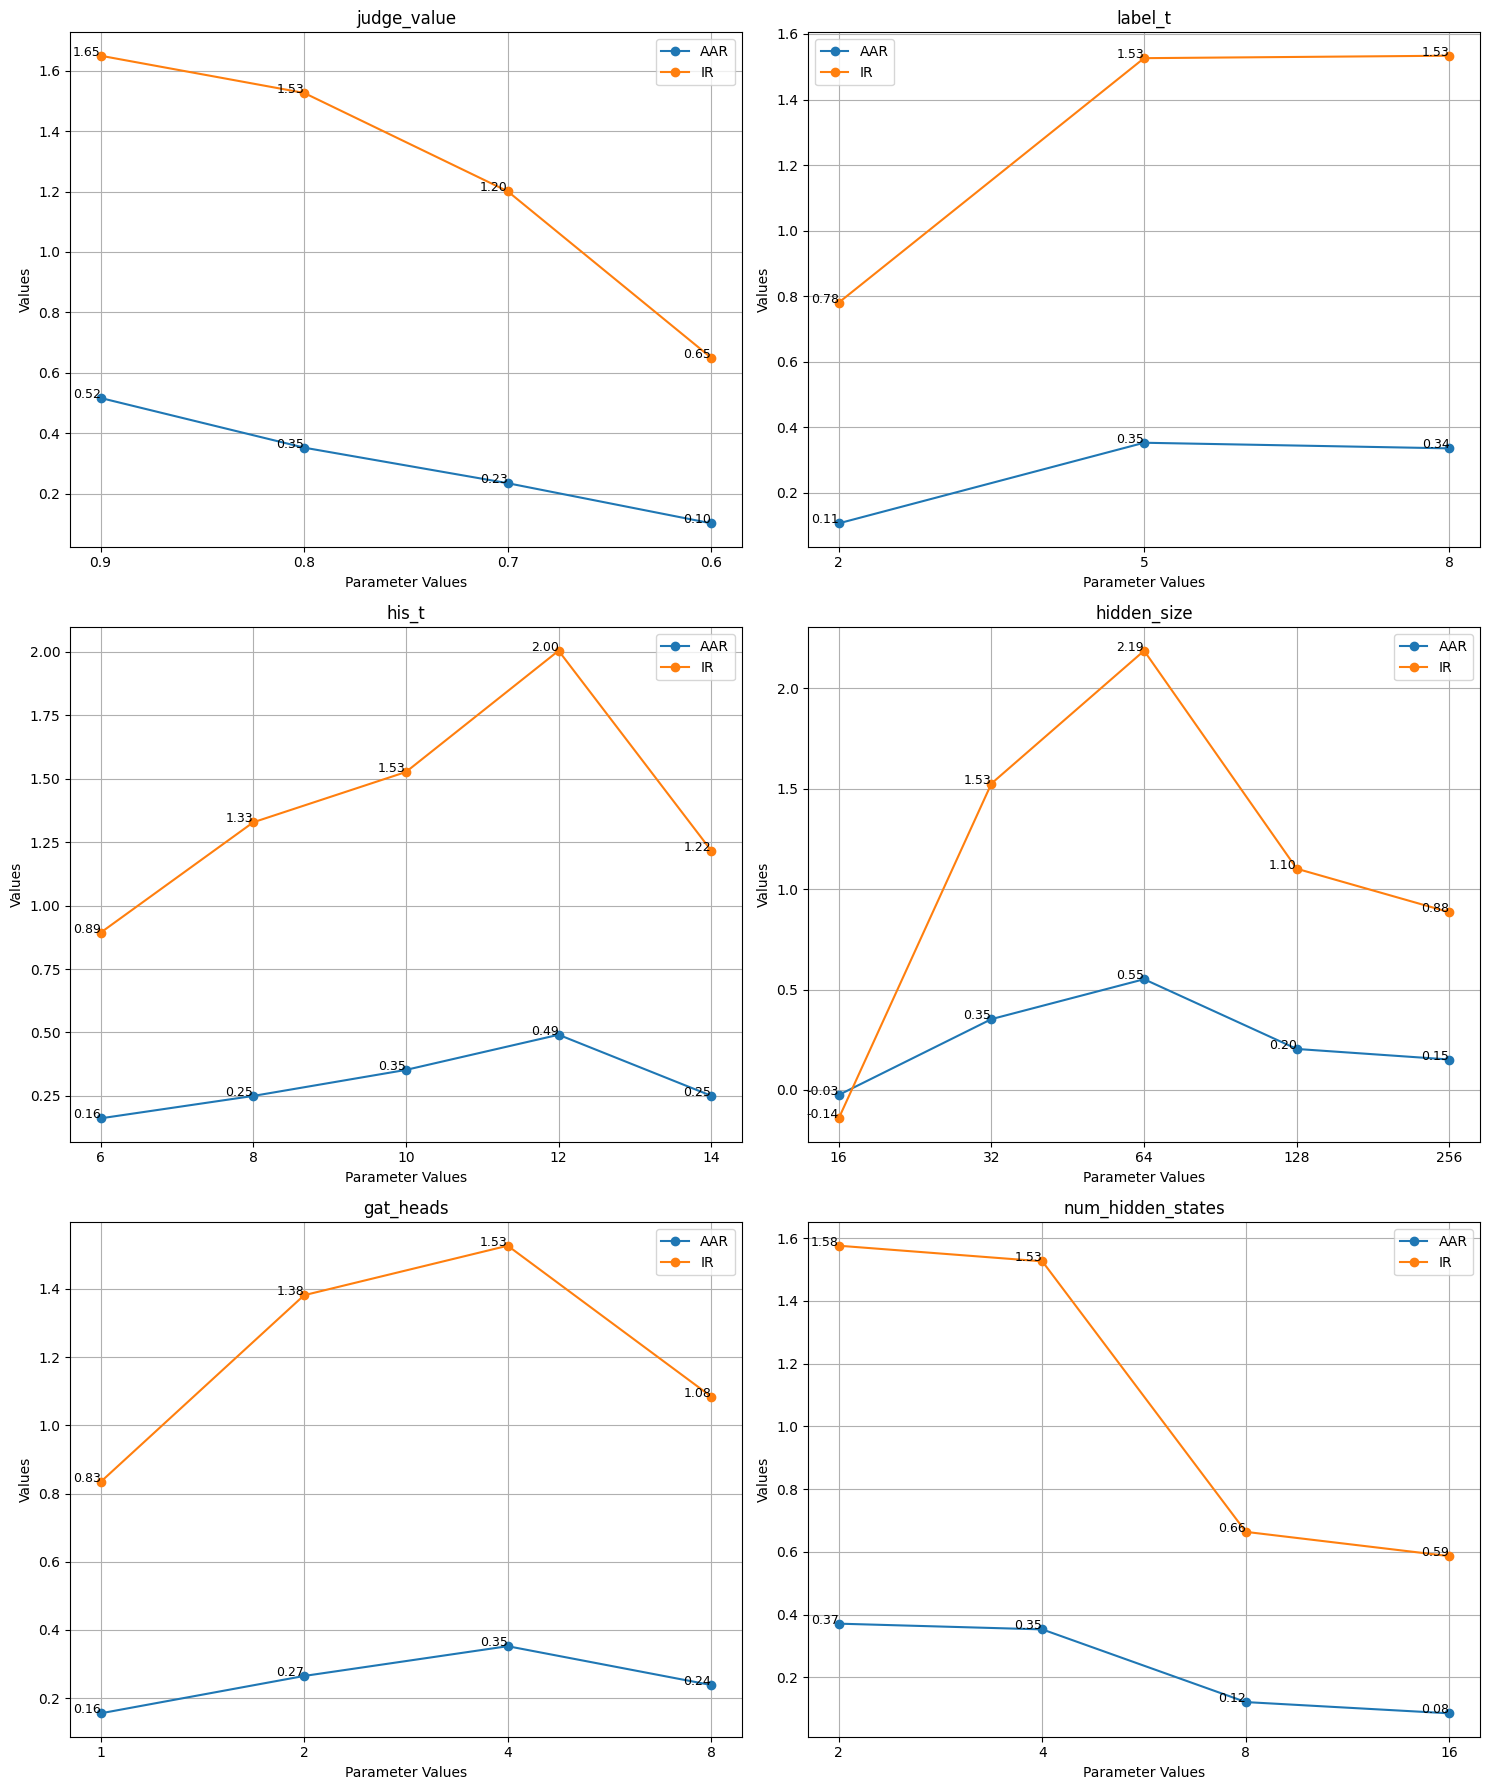

In [10]:
import matplotlib.pyplot as plt

# Data provided by the user
data = {
    'judge_value': {
        'params': [0.9, 0.8, 0.7, 0.6],
        'AAR': [0.516938, 0.352498, 0.234912, 0.102060],
        'IR': [1.649359, 1.526197, 1.200668, 0.649852]
    },
    'label_t': {
        'params': [2, 5, 8],
        'AAR': [0.106532, 0.352498, 0.335363],
        'IR': [0.780286, 1.526197, 1.533677]
    },
    'his_t': {
        'params': [6, 8, 10, 12, 14],
        'AAR': [0.161684, 0.249962, 0.352498, 0.490968, 0.250563],
        'IR': [0.893002, 1.327974, 1.526197, 2.003995, 1.216348]
    },
    'hidden_size': {
        'params': [16, 32, 64, 128, 256],
        'AAR': [-0.025242, 0.352498, 0.551383, 0.203915, 0.151250],
        'IR': [-0.141760, 1.526197, 2.187934, 1.101704, 0.884965]
    },
    'gat_heads': {
        'params': [1, 2, 4, 8],
        'AAR': [0.155718, 0.265274, 0.352498, 0.238667],
        'IR': [0.833769, 1.381152, 1.526197, 1.083928]
    },
    'num_hidden_states': {
        'params': [2, 4, 8, 16],
        'AAR': [0.370808, 0.352498, 0.120734, 0.084814],
        'IR': [1.576103, 1.526197, 0.663528, 0.586095]
    }
}

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, (key, value) in enumerate(data.items()):
    # Mapping parameter values to string positions for x-axis
    param_positions = range(len(value['params']))
    param_labels = [str(p) for p in value['params']]
    
    axes[i].plot(param_positions, value['AAR'], marker='o', linestyle='-', label='AAR')
    axes[i].plot(param_positions, value['IR'], marker='o', linestyle='-', label='IR')
    for pos, y in zip(param_positions, value['AAR']):
        axes[i].text(pos, y, f'{y:.2f}', fontsize=9, ha='right')
    for pos, y in zip(param_positions, value['IR']):
        axes[i].text(pos, y, f'{y:.2f}', fontsize=9, ha='right')
    axes[i].set_title(key)
    axes[i].set_xlabel('Parameter Values')
    axes[i].set_ylabel('Values')
    axes[i].set_xticks(param_positions)
    axes[i].set_xticklabels(param_labels)
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()


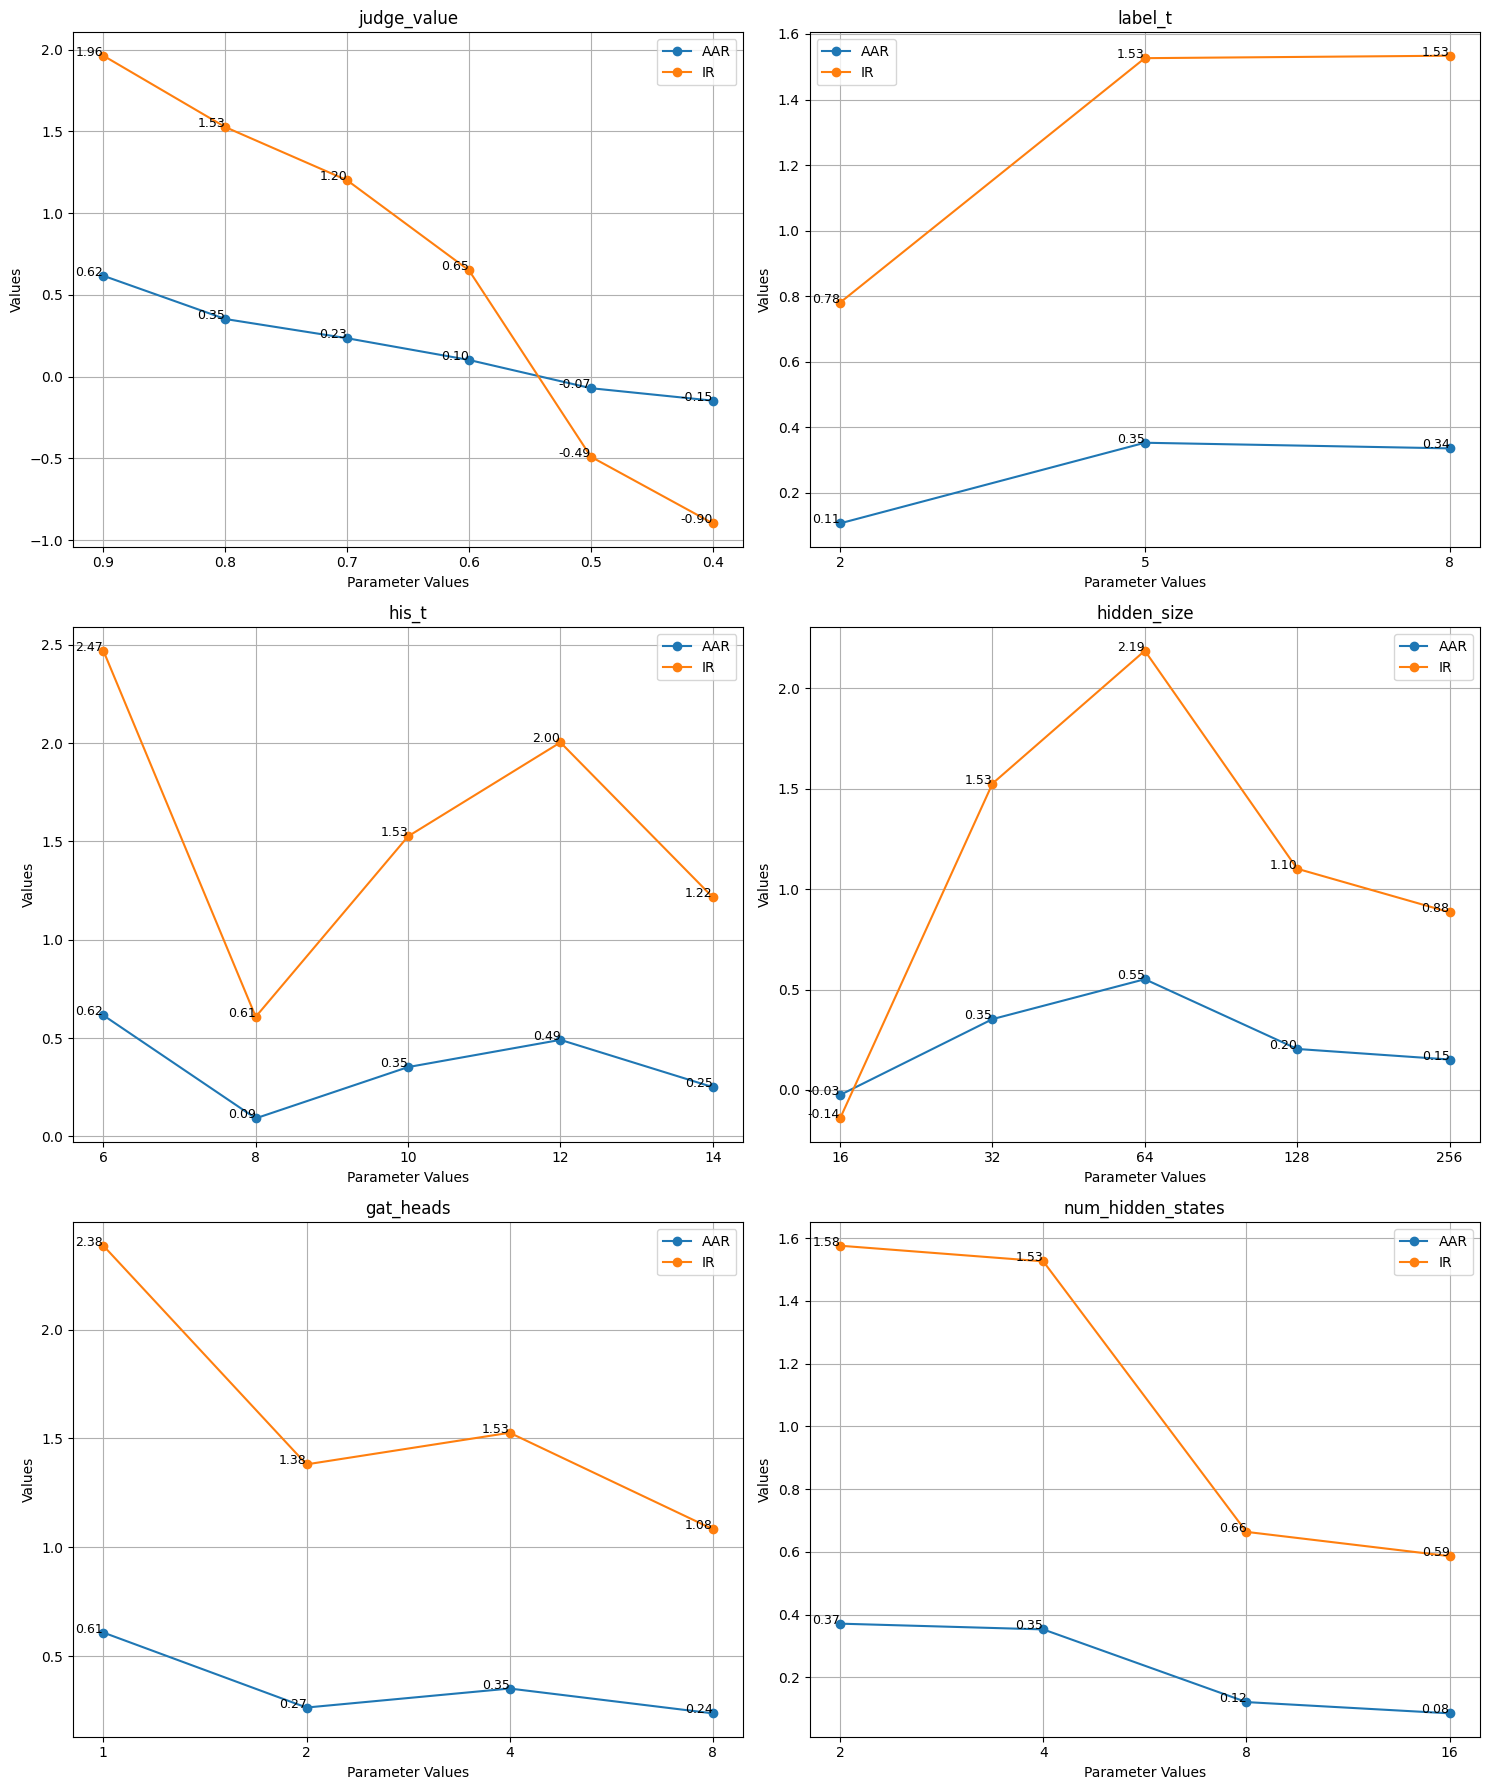

In [5]:
import matplotlib.pyplot as plt

# Data provided by the user
data = {
    'judge_value': {
        'params': [0.9, 0.8, 0.7, 0.6, 0.5, 0.4],
        'AAR': [0.616819, 0.352498, 0.234912, 0.102060, -0.070595, -0.146778],
        'IR': [1.962465, 1.526197, 1.200668, 0.649852, -0.489760, -0.896947]
    },
    'label_t': {
        'params': [2, 5, 8],
        'AAR': [0.106532, 0.352498, 0.335363],
        'IR': [0.780286, 1.526197, 1.533677]
    },
    'his_t': {
        'params': [6, 8, 10, 12, 14],
        'AAR': [0.615723, 0.091748, 0.352498, 0.490968, 0.250563],
        'IR': [2.470333, 0.608266, 1.526197, 2.003995, 1.216348]
    },
    'hidden_size': {
        'params': [16, 32, 64, 128, 256],
        'AAR': [-0.025242, 0.352498, 0.551383, 0.203915, 0.151250],
        'IR': [-0.141760, 1.526197, 2.187934, 1.101704, 0.884965]
    },
    'gat_heads': {
        'params': [1, 2, 4, 8],
        'AAR': [0.609341, 0.265274, 0.352498, 0.238667],
        'IR': [2.384512, 1.381152, 1.526197, 1.083928]
    },
    'num_hidden_states': {
        'params': [2, 4, 8, 16],
        'AAR': [0.370808, 0.352498, 0.120734, 0.084814],
        'IR': [1.576103, 1.526197, 0.663528, 0.586095]
    }
}

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, (key, value) in enumerate(data.items()):
    # Mapping parameter values to string positions for x-axis
    param_positions = range(len(value['params']))
    param_labels = [str(p) for p in value['params']]
    
    axes[i].plot(param_positions, value['AAR'], marker='o', linestyle='-', label='AAR')
    axes[i].plot(param_positions, value['IR'], marker='o', linestyle='-', label='IR')
    for pos, y in zip(param_positions, value['AAR']):
        axes[i].text(pos, y, f'{y:.2f}', fontsize=9, ha='right')
    for pos, y in zip(param_positions, value['IR']):
        axes[i].text(pos, y, f'{y:.2f}', fontsize=9, ha='right')
    axes[i].set_title(key)
    axes[i].set_xlabel('Parameter Values')
    axes[i].set_ylabel('Values')
    axes[i].set_xticks(param_positions)
    axes[i].set_xticklabels(param_labels)
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()
